# Time-Series Forecasting: ARIMA and Prophet

##  Time-Series Forecasting

This project focuses on forecasting daily minimum temperature using classical time-series models.

### Objectives
- Examine the structure of the time-series dataset.
- Analyze trend and seasonality.
- Test stationarity using the Augmented Dickey-Fuller (ADF) test.
- Analyze autocorrelation using ACF and PACF.
- Build an ARIMA forecasting model.
- Build a Prophet forecasting model.
- Evaluate and compare both models using MAE, RMSE, and MAPE.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Dataset Loading

The daily minimum temperature dataset is loaded into a pandas DataFrame for further analysis.


In [3]:
# Load the dataset

df = pd.read_csv("daily-min-temperatures.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (3650, 2)


,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [4]:
# Examine dataset structure

print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Columns:
['Date', 'Temp']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   str    
 1   Temp    3650 non-null   float64
dtypes: float64(1), str(1)
memory usage: 57.2 KB

Missing Values:
Date    0
Temp    0
dtype: int64


## 3. Date Conversion and Time-Series Preparation

The `Date` column is converted from text format to datetime format. The dataset is then sorted chronologically and the date is set as the time-series index.

In [5]:
# Convert Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"])

# Sort data by date
df = df.sort_values("Date")

# Set Date as the index
df = df.set_index("Date")

print("Date conversion completed successfully!")
print("Data Type of Index:", df.index.dtype)
print("Date Range:", df.index.min(), "to", df.index.max())

display(df.head())

Date conversion completed successfully!
Data Type of Index: datetime64[us]
Date Range: 1981-01-01 00:00:00 to 1990-12-31 00:00:00


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


## 4. Exploratory Data Analysis

The daily minimum temperature series is visualized over time to identify overall trends, fluctuations, and possible seasonal patterns.

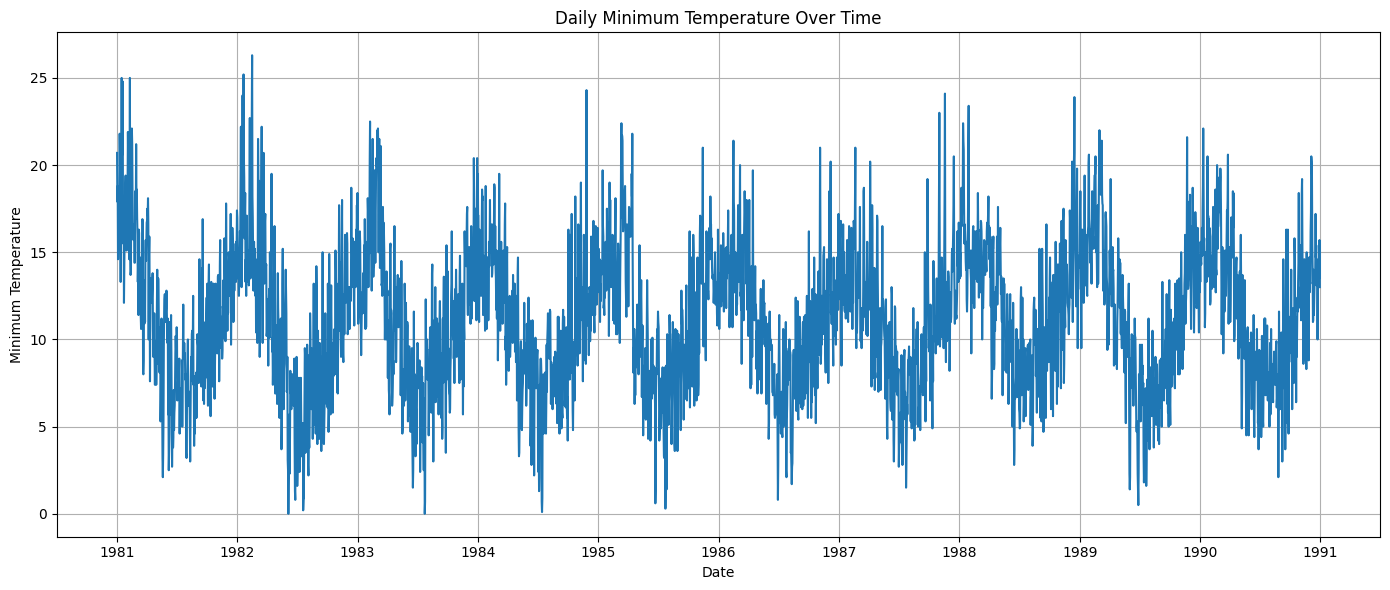

In [6]:
# Plot the daily minimum temperature over time

plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Temp"])

plt.title("Daily Minimum Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Minimum Temperature")
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Stationarity Test — Augmented Dickey-Fuller (ADF)

The Augmented Dickey-Fuller (ADF) test is used to determine whether the time series is stationary.

A stationary series has statistical properties that remain relatively stable over time.

- Null Hypothesis (H₀): The series is non-stationary.
- Alternative Hypothesis (H₁): The series is stationary.
- If p-value < 0.05, we reject H₀ and consider the series stationary.






In [7]:
# Perform Augmented Dickey-Fuller (ADF) test

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df["Temp"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

if adf_result[1] < 0.05:
    print("\nConclusion: The series is stationary.")
else:
    print("\nConclusion: The series is non-stationary.")

ADF Statistic: -4.444804924611687
p-value: 0.00024708263003611164
Critical Values:
   1%: -3.4321532327220154
   5%: -2.862336767636517
   10%: -2.56719413172842

Conclusion: The series is stationary.


## 6. Autocorrelation Analysis — ACF and PACF

The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) are plotted to examine the relationship between current temperature values and their previous observations.

- ACF helps identify the correlation between observations and their lagged values.
- PACF measures the direct relationship between an observation and its lag while controlling for intermediate lags.

These plots help guide the selection of ARIMA model parameters.


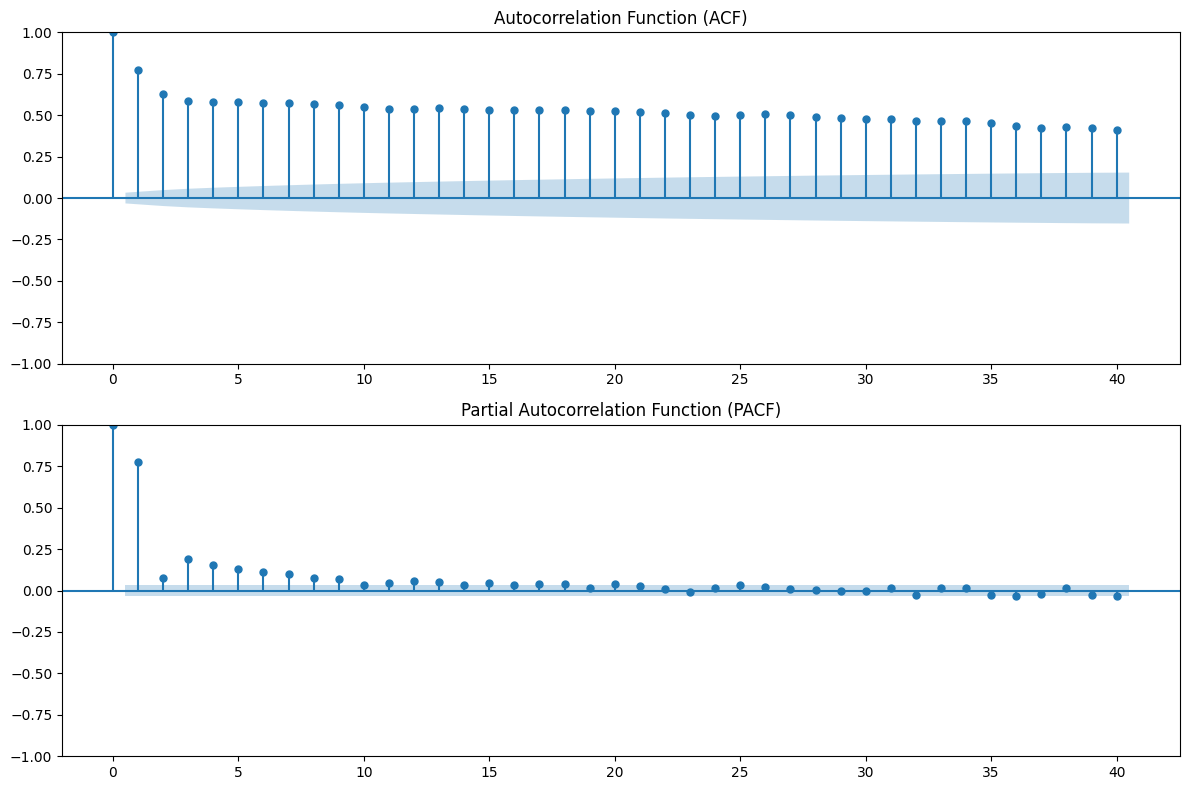

In [8]:
# Import required libraries for ACF and PACF analysis

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Create ACF and PACF plots
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF plot
plot_acf(df["Temp"], lags=40, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")

# PACF plot
plot_pacf(df["Temp"], lags=40, ax=axes[1], method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

## 7. Train-Test Split

The dataset is divided chronologically into training and testing sets.

The first 80% of observations are used to train the forecasting model, while the last 20% are kept for evaluating forecast performance on unseen data.

In [9]:
# Train-Test Split

train_size = int(len(df) * 0.80)

train = df["Temp"].iloc[:train_size]
test = df["Temp"].iloc[train_size:]

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Training period:", train.index.min(), "to", train.index.max())
print("Testing period:", test.index.min(), "to", test.index.max())

Training observations: 2920
Testing observations: 730
Training period: 1981-01-01 00:00:00 to 1988-12-30 00:00:00
Testing period: 1989-01-01 00:00:00 to 1990-12-31 00:00:00


## 8. ARIMA Model

An ARIMA model is used to forecast future temperature values based on historical observations.

The model is represented as ARIMA(p, d, q), where:
- p = autoregressive (AR) order
- d = degree of differencing
- q = moving average (MA) order

Since the ADF test showed that the temperature series is stationary, we start with d = 0.

In [10]:
# Build and fit ARIMA model

from statsmodels.tsa.arima.model import ARIMA

# ARIMA(p, d, q)
model = ARIMA(train, order=(2, 0, 2))

arima_model = model.fit()

print("ARIMA(2,0,2) model fitted successfully!")
print("AIC:", arima_model.aic)
print("BIC:", arima_model.bic)

d:\install\python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\install\python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\install\python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\install\python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


ARIMA(2,0,2) model fitted successfully!
AIC: 13540.955823566608
BIC: 13576.831856938183


## 9. ARIMA Forecast with 95% Confidence Interval

The fitted ARIMA model is used to forecast temperature values for the complete testing period.

A 95% confidence interval is also calculated to represent the uncertainty around the forecasted values. The forecast is then compared with the actual test observations.

In [11]:
# Generate ARIMA forecasts for the test period

arima_forecast_result = arima_model.get_forecast(steps=len(test))

arima_forecast = arima_forecast_result.predicted_mean
arima_conf_int = arima_forecast_result.conf_int()

print("ARIMA forecast generated successfully!")
print("Forecast observations:", len(arima_forecast))

display(arima_forecast.head()) 

ARIMA forecast generated successfully!
Forecast observations: 730


d:\install\python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\install\python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


2920    14.229179
2921    14.439578
2922    14.472717
2923    14.463957
2924    14.445386
Name: predicted_mean, dtype: float64

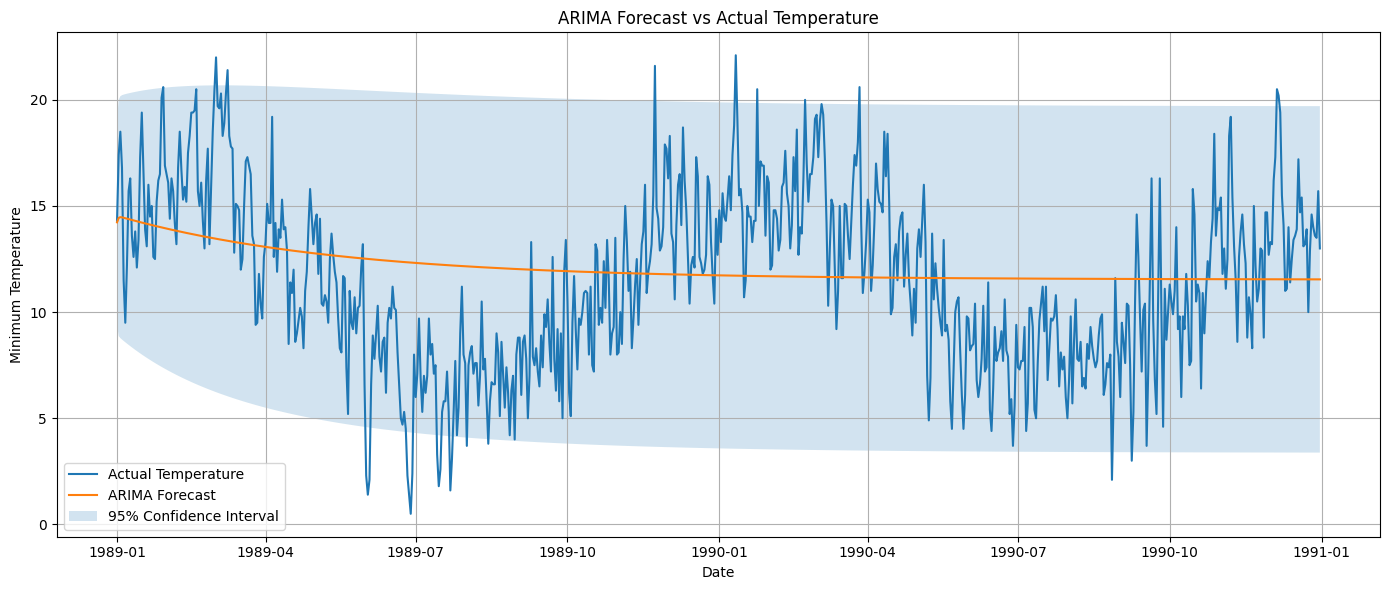

In [12]:
# Plot actual vs predicted temperature with 95% confidence interval

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(test.index, test.values, label="Actual Temperature")
plt.plot(test.index, arima_forecast.values, label="ARIMA Forecast")

plt.fill_between(
    test.index,
    arima_conf_int.iloc[:, 0],
    arima_conf_int.iloc[:, 1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("ARIMA Forecast vs Actual Temperature")
plt.xlabel("Date")
plt.ylabel("Minimum Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. ARIMA Model Evaluation

The ARIMA model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

These metrics measure the difference between the actual temperature values and the ARIMA forecasts. Lower values indicate better forecasting performance.

In [13]:
# Evaluate ARIMA forecast performance

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(test, arima_forecast)

rmse_arima = np.sqrt(
    mean_squared_error(test, arima_forecast)
)

mape_arima = np.mean(
    np.abs((test.values - arima_forecast.values) / test.values)
) * 100

print("ARIMA Evaluation Results")
print("------------------------")
print(f"MAE  : {mae_arima:.4f}")
print(f"RMSE : {rmse_arima:.4f}")
print(f"MAPE : {mape_arima:.2f}%")

ARIMA Evaluation Results
------------------------
MAE  : 3.3162
RMSE : 4.0284
MAPE : 45.72%


## 11. Preparing Data for Prophet

Prophet requires the input data to contain two columns:

- `ds`: Date/time column
- `y`: Target value to be forecast

The training dataset is therefore converted into the required Prophet format.

In [14]:
# Prepare training data for Prophet

prophet_train = train.reset_index()

prophet_train = prophet_train.rename(
    columns={
        "Date": "ds",
        "Temp": "y"
    }
)

# Ensure correct data types
prophet_train["ds"] = pd.to_datetime(prophet_train["ds"])

print("Prophet training data prepared successfully!")
print("Shape:", prophet_train.shape)

display(prophet_train.head())

Prophet training data prepared successfully!
Shape: (2920, 2)


,ds,y
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


## 12. Building the Prophet Model

A Prophet model is trained on the prepared training data.

The model automatically captures the underlying trend and daily/seasonal patterns in the temperature time series.

In [15]:
# Build and train the Prophet model

from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)

prophet_model.fit(prophet_train)

print("Prophet model fitted successfully!")

C:\Users\Murtaza Khalid\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
00:23:48 - cmdstanpy - INFO - Chain [1] start processing
00:23:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted successfully!


## 13. Prophet Forecast

The trained Prophet model is used to generate forecasts for the testing period.

A 95% confidence interval is included to represent the uncertainty of the predictions.

In [16]:
# Generate Prophet forecasts exactly for the test dates

future_test = pd.DataFrame({
    "ds": test.index
})

prophet_test_forecast = prophet_model.predict(future_test)

print("Prophet forecast generated successfully!")
print("Forecast observations:", len(prophet_test_forecast))

display(
    prophet_test_forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].head()
)

Prophet forecast generated successfully!
Forecast observations: 730


,ds,yhat,yhat_lower,yhat_upper
0,1989-01-01,15.539965,10.374606,21.116211
1,1989-01-02,15.841298,10.475699,21.265045
2,1989-01-03,15.992818,10.320609,21.290299
3,1989-01-04,16.049666,10.810474,21.487904
4,1989-01-05,15.931896,10.715923,21.457497


## Step 14: Prophet Forecast Visualization

This graph compares the actual temperature values from the test set with the
temperature values predicted by the Prophet model.

The shaded region represents the uncertainty interval of the forecast.

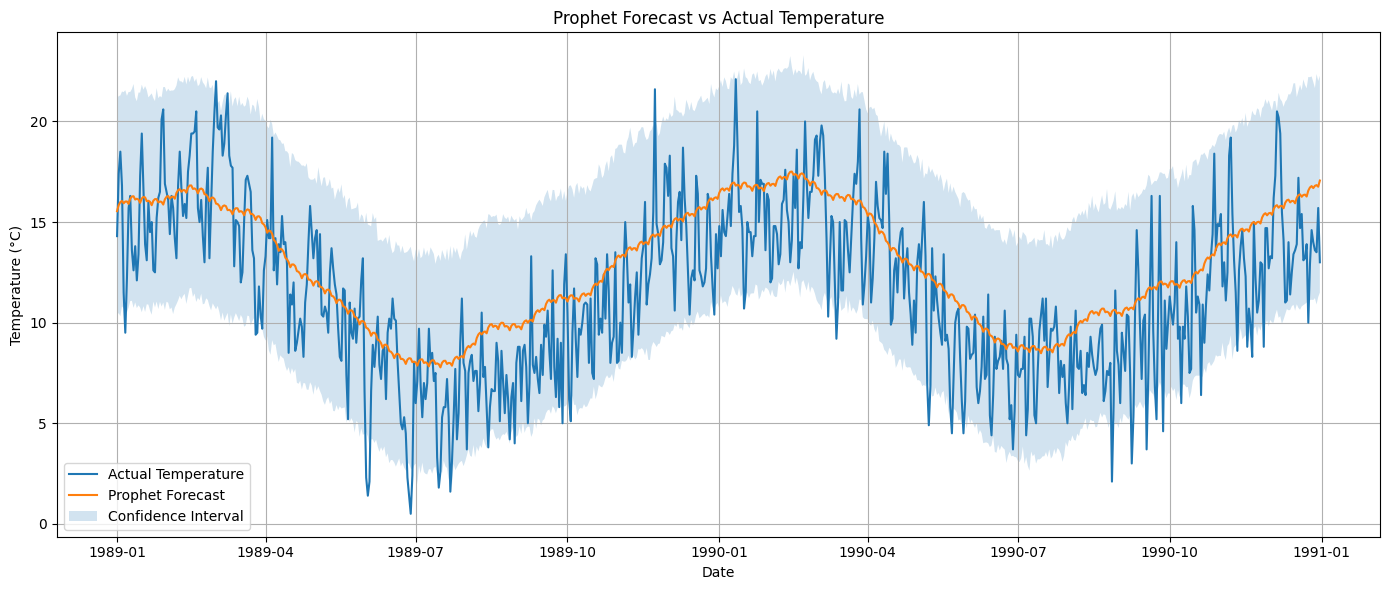

In [18]:
# Step 14: Prophet Actual vs Forecast

plt.figure(figsize=(14, 6))

# Actual test temperatures
plt.plot(
    test.index,
    test.values,
    label="Actual Temperature"
)

# Prophet forecast
plt.plot(
    prophet_test_forecast["ds"],
    prophet_test_forecast["yhat"],
    label="Prophet Forecast"
)

# Uncertainty interval
plt.fill_between(
    prophet_test_forecast["ds"],
    prophet_test_forecast["yhat_lower"],
    prophet_test_forecast["yhat_upper"],
    alpha=0.2,
    label="Confidence Interval"
)

plt.title("Prophet Forecast vs Actual Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

## Step 15: Prophet Model Evaluation

The Prophet model is evaluated using Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

These metrics are calculated by comparing the actual test temperatures
with the Prophet forecast. 

In [19]:
# Step 15: Evaluate Prophet Forecast

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual and predicted values
actual = test.values
predicted = prophet_test_forecast["yhat"].values

# Calculate metrics
prophet_mae = mean_absolute_error(actual, predicted)
prophet_rmse = np.sqrt(mean_squared_error(actual, predicted))
prophet_mape = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

print("Prophet Model Evaluation")
print("------------------------")
print(f"MAE  : {prophet_mae:.4f}")
print(f"RMSE : {prophet_rmse:.4f}")
print(f"MAPE : {prophet_mape:.2f}%")

Prophet Model Evaluation
------------------------
MAE  : 2.3719
RMSE : 2.9189
MAPE : 32.28%


## Step 16: ARIMA vs Prophet Model Comparison

The performance of the ARIMA and Prophet models is compared using
MAE, RMSE, and MAPE.

Lower values indicate better forecasting performance. 

In [20]:
# Step 16: ARIMA vs Prophet Comparison

comparison = pd.DataFrame({
    "Model": ["ARIMA", "Prophet"],
    "MAE": [3.3162, prophet_mae],
    "RMSE": [4.0284, prophet_rmse],
    "MAPE (%)": [45.72, prophet_mape]
})

display(comparison)

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,3.316200,4.02840,45.720000
1,Prophet,2.371866,2.91888,32.280222


## Step 17: Best Model Selection

The ARIMA and Prophet models are compared based on MAE, RMSE, and MAPE.
The model with lower forecasting errors is considered the better-performing model. 

In [21]:
# Step 17: Identify the Best Forecasting Model

best_mae_model = comparison.loc[comparison["MAE"].idxmin(), "Model"]
best_rmse_model = comparison.loc[comparison["RMSE"].idxmin(), "Model"]
best_mape_model = comparison.loc[comparison["MAPE (%)"].idxmin(), "Model"]

print("Best Model Based on Evaluation Metrics")
print("--------------------------------------")
print(f"Lowest MAE  : {best_mae_model}")
print(f"Lowest RMSE : {best_rmse_model}")
print(f"Lowest MAPE : {best_mape_model}")

if best_mae_model == best_rmse_model == best_mape_model:
    print(f"\nOverall Best Model: {best_mae_model}")
else:
    print("\nThe models show mixed performance across the evaluation metrics.")

Best Model Based on Evaluation Metrics
--------------------------------------
Lowest MAE  : Prophet
Lowest RMSE : Prophet
Lowest MAPE : Prophet

Overall Best Model: Prophet


## Step 18: Model Comparison Analysis

Both ARIMA and Prophet were evaluated using the same test dataset and
the same evaluation metrics. The results show that Prophet performed
better than ARIMA in all three metrics.

ARIMA achieved a Mean Absolute Error (MAE) of 3.3162, Root Mean Squared
Error (RMSE) of 4.0284, and Mean Absolute Percentage Error (MAPE) of
45.72%. In comparison, Prophet achieved a lower MAE of 2.3719, RMSE of
2.9189, and MAPE of 32.28%.

The lower MAE indicates that Prophet's predictions were closer to the
actual temperature values on average. The lower RMSE also shows that
Prophet produced fewer large prediction errors. Similarly, the lower
MAPE indicates better percentage-based forecasting accuracy.

The temperature dataset contains clear seasonal patterns across the
years. Prophet is designed to model trend and seasonality effectively,
which helps it capture the recurring temperature patterns in the data.
The Prophet forecast graph also shows that the predicted values follow
the overall seasonal movement of the actual temperature series.

ARIMA is also useful for time-series forecasting and performed reasonably
well on this dataset. However, its forecasting performance was weaker
than Prophet according to all three evaluation metrics.

Based on the experimental results, Prophet is selected as the better
forecasting model for this dataset. It achieved the lowest MAE, RMSE,
and MAPE among the two models. Therefore, Prophet provides more accurate
forecasts for the daily minimum temperature data used in this analysis. 

## Step 19: Save Model Comparison Table

The ARIMA and Prophet evaluation results are saved as a CSV file
for documentation and submission. 


In [22]:
# Step 19: Save Comparison Table

comparison.to_csv("ARIMA_vs_Prophet_Comparison.csv", index=False)

print("Comparison table saved successfully!")
print("File: ARIMA_vs_Prophet_Comparison.csv")

Comparison table saved successfully!
File: ARIMA_vs_Prophet_Comparison.csv
